# Prova de Conceito — Machine Learning para Previsão de Evasão
### Projeto Integrador — Evasão Escolar em Cubatão-SP

**Objetivo deste notebook:** demonstrar, com uma base de dados pública e rotulada, como um modelo de Machine Learning de verdade (não uma regra de pontos fixa) prevê evasão escolar — e depois discutir como aplicar a mesma lógica de variáveis (features) à estrutura de dados que já temos de Cubatão.

**Por que uma base externa?** Os dados de Cubatão que reunimos (Censo Escolar, Taxas de Rendimento, frequência de 2026) não têm um **rótulo de resultado por aluno** — ou seja, não sabemos quais alunos específicos evadiram ou não. Só existe a taxa agregada da rede. Machine Learning supervisionado precisa desse rótulo para aprender. Por isso, praticamos a técnica em uma base que já tem esse rótulo, documentada academicamente:

> Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). **Predict Students' Dropout and Academic Success** [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89

4.424 alunos reais de uma instituição de ensino superior portuguesa, com 36 variáveis (demográficas, socioeconômicas, acadêmicas) e o resultado final: **Evasão**, **Matriculado** (ainda cursando) ou **Diplomado**.

Os nomes das colunas e das classes foram traduzidos para português abaixo, para facilitar a leitura no PI.


In [1]:
# 0. Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (9, 5)

DADOS = "dados"


## 1. Carregar, traduzir e explorar a base

In [2]:
# 1.1 Carregar e traduzir nomes de colunas e classes para português
df = pd.read_csv(f"../dados_escola_cubatao_completo/uci_dropout_dataset.csv")
df.columns = [c.strip() for c in df.columns]

TRADUCAO_COLUNAS = {
    'Marital status': 'Estado civil',
    'Application mode': 'Modo de candidatura',
    'Application order': 'Ordem de candidatura',
    'Course': 'Curso',
    'Daytime/evening attendance': 'Turno (diurno/noturno)',
    'Previous qualification': 'Qualificação anterior',
    'Nacionality': 'Nacionalidade',
    "Mother's qualification": 'Qualificação da mãe',
    "Father's qualification": 'Qualificação do pai',
    "Mother's occupation": 'Ocupação da mãe',
    "Father's occupation": 'Ocupação do pai',
    'Displaced': 'Deslocado',
    'Educational special needs': 'Necessidades educativas especiais',
    'Debtor': 'Devedor',
    'Tuition fees up to date': 'Mensalidades em dia',
    'Gender': 'Gênero',
    'Scholarship holder': 'Bolsista',
    'Age at enrollment': 'Idade na matrícula',
    'International': 'Internacional',
    'Curricular units 1st sem (credited)': 'Unidades curric. 1º sem (creditadas)',
    'Curricular units 1st sem (enrolled)': 'Unidades curric. 1º sem (matriculadas)',
    'Curricular units 1st sem (evaluations)': 'Unidades curric. 1º sem (avaliações)',
    'Curricular units 1st sem (approved)': 'Unidades curric. 1º sem (aprovadas)',
    'Curricular units 1st sem (grade)': 'Unidades curric. 1º sem (nota)',
    'Curricular units 1st sem (without evaluations)': 'Unidades curric. 1º sem (sem avaliação)',
    'Curricular units 2nd sem (credited)': 'Unidades curric. 2º sem (creditadas)',
    'Curricular units 2nd sem (enrolled)': 'Unidades curric. 2º sem (matriculadas)',
    'Curricular units 2nd sem (evaluations)': 'Unidades curric. 2º sem (avaliações)',
    'Curricular units 2nd sem (approved)': 'Unidades curric. 2º sem (aprovadas)',
    'Curricular units 2nd sem (grade)': 'Unidades curric. 2º sem (nota)',
    'Curricular units 2nd sem (without evaluations)': 'Unidades curric. 2º sem (sem avaliação)',
    'Unemployment rate': 'Taxa de desemprego',
    'Inflation rate': 'Taxa de inflação',
    'GDP': 'PIB',
    'Target': 'Resultado',
}
TRADUCAO_CLASSES = {'Dropout': 'Abandono', 'Enrolled': 'Matriculado', 'Graduate': 'Diplomado'}

df = df.rename(columns=TRADUCAO_COLUNAS)
df['Resultado'] = df['Resultado'].map(TRADUCAO_CLASSES)

print(f"Alunos: {len(df)} | Variáveis: {df.shape[1] - 1} (+ 1 alvo)")
df['Resultado'].value_counts()


Alunos: 4424 | Variáveis: 34 (+ 1 alvo)


Resultado
Diplomado      2209
Abandono       1421
Matriculado     794
Name: count, dtype: int64

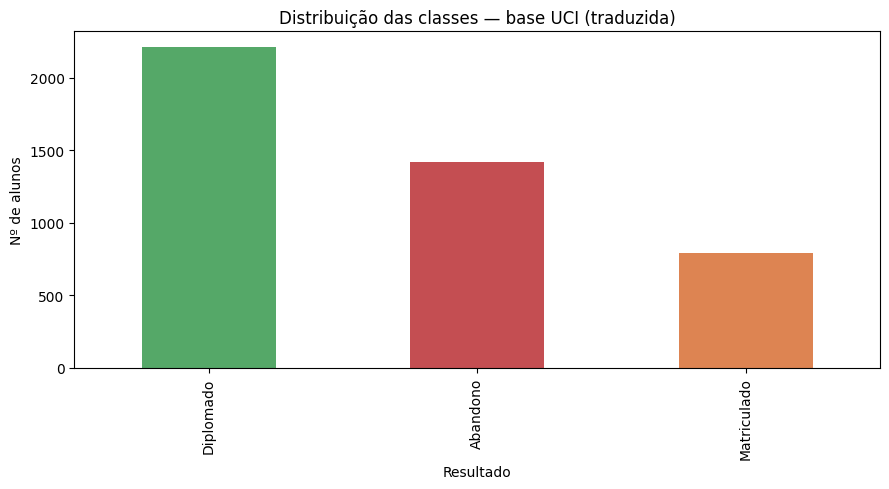

In [3]:
# 1.2 Distribuição das classes
fig, ax = plt.subplots()
df['Resultado'].value_counts().plot(kind='bar', ax=ax, color=['#55A868', '#C44E52', '#DD8452'])
ax.set_ylabel('Nº de alunos')
ax.set_title('Distribuição das classes — base UCI (traduzida)')
plt.tight_layout()
plt.show()


## 2. Preparar os dados para o modelo

Todas as variáveis já vêm numéricas/codificadas na base original (categorias como códigos inteiros). Separamos features (X) e alvo (y), e dividimos em treino/teste.


In [4]:
# 2.1 Separar X (features) e y (alvo)
X = df.drop(columns=['Resultado'])
y = df['Resultado']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Treino: {len(X_train)} alunos | Teste: {len(X_test)} alunos")


Treino: 3318 alunos | Teste: 1106 alunos


In [5]:
# 2.2 Padronizar as variáveis (necessário para Regressão Logística; Random Forest não exige, mas não atrapalha)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 3. Treinar dois modelos e comparar

Regressão Logística (mais simples e interpretável) e Random Forest (mais robusto, geralmente com melhor desempenho neste tipo de problema).


In [6]:
# 3.1 Regressão Logística
modelo_lr = LogisticRegression(max_iter=2000, random_state=42)
modelo_lr.fit(X_train_scaled, y_train)
pred_lr = modelo_lr.predict(X_test_scaled)

print("=== Regressão Logística ===")
print(classification_report(y_test, pred_lr))


=== Regressão Logística ===
              precision    recall  f1-score   support

    Abandono       0.81      0.75      0.78       355
   Diplomado       0.79      0.93      0.85       552
 Matriculado       0.50      0.31      0.39       199

    accuracy                           0.76      1106
   macro avg       0.70      0.66      0.67      1106
weighted avg       0.74      0.76      0.74      1106



In [7]:
# 3.2 Random Forest
modelo_rf = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=12)
modelo_rf.fit(X_train, y_train)  # Random Forest não precisa de padronização
pred_rf = modelo_rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, pred_rf))


=== Random Forest ===
              precision    recall  f1-score   support

    Abandono       0.84      0.72      0.77       355
   Diplomado       0.77      0.96      0.85       552
 Matriculado       0.60      0.33      0.43       199

    accuracy                           0.77      1106
   macro avg       0.73      0.67      0.68      1106
weighted avg       0.76      0.77      0.75      1106



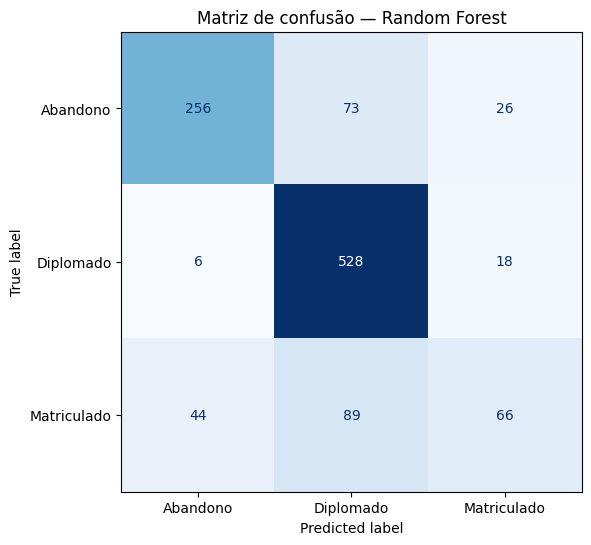

In [8]:
# 3.3 Matriz de confusão do melhor modelo (Random Forest)
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, pred_rf, ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de confusão — Random Forest')
plt.tight_layout()
plt.show()


## 4. Quais variáveis mais pesam na previsão?

Esta é a parte mais útil para o PI: entender **quais tipos de variável realmente importam**, para saber o que vale a pena coletar em Cubatão.


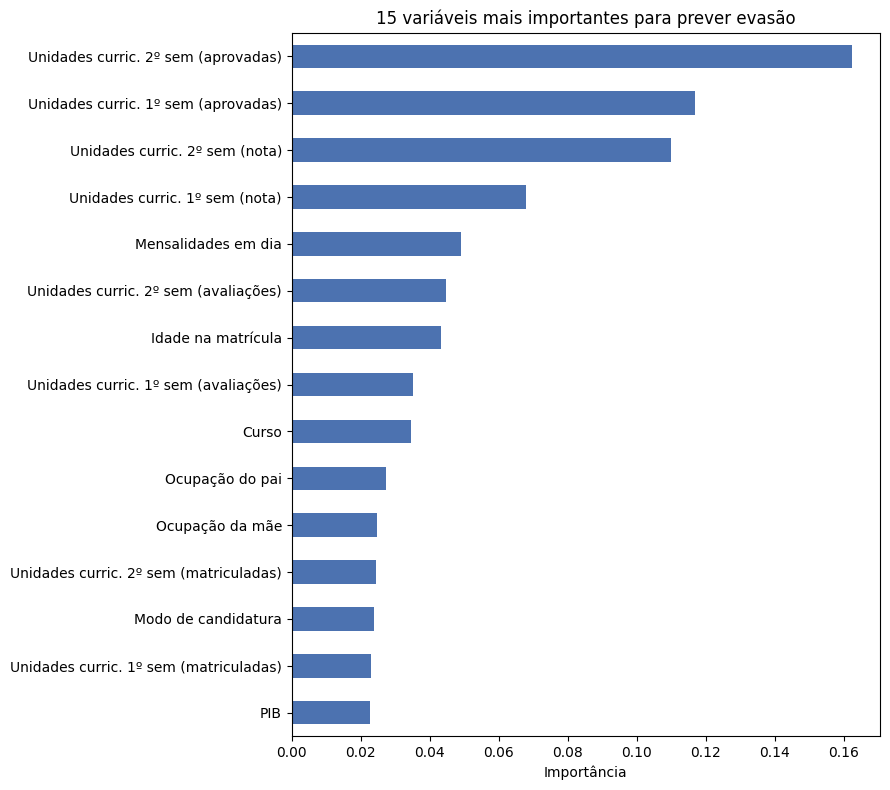

Unidades curric. 2º sem (aprovadas)     0.162345
Unidades curric. 1º sem (aprovadas)     0.116819
Unidades curric. 2º sem (nota)          0.110019
Unidades curric. 1º sem (nota)          0.067939
Mensalidades em dia                     0.048987
Unidades curric. 2º sem (avaliações)    0.044792
Idade na matrícula                      0.043146
Unidades curric. 1º sem (avaliações)    0.035073
Curso                                   0.034692
Ocupação do pai                         0.027240
dtype: float64

In [9]:
# 4.1 Importância das variáveis (Random Forest)
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
importancias.head(15).sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('Importância')
ax.set_title('15 variáveis mais importantes para prever evasão')
plt.tight_layout()
plt.show()

importancias.head(10)


### Leitura do resultado

As variáveis mais importantes tendem a ser as **acadêmicas do próprio percurso** (unidades curriculares aprovadas/avaliadas no 1º e 2º semestre) — não as demográficas ou socioeconômicas isoladas. Isso é uma boa notícia para o PI: o tipo de dado que já vimos coletando em Cubatão (frequência, aprovação, reprovação) é **exatamente a categoria de variável que mais importa** neste problema, segundo o modelo — mesmo sem dados socioeconômicos.


## 5. Traduzindo para a estrutura de dados de Cubatão

| Variável na base (traduzida) | Equivalente em Cubatão (o que já coletamos) |
|---|---|
| Unidades curric. 1º/2º sem (matriculadas) | Aulas previstas no bimestre/trimestre (`aulas_previstas`) |
| Unidades curric. 1º/2º sem (aprovadas) | Frequência/aprovação por período — via Taxas de Rendimento |
| Unidades curric. 1º/2º sem (avaliações) | Registros de chamada no período |
| Unidades curric. 1º/2º sem (nota) | Não coletado ainda (notas por aluno) |
| Idade na matrícula | Pouco variável dentro de uma única série (7º ano) |
| Bolsista / Devedor / Mensalidades em dia | Não aplicável/não deve ser coletado (dado sensível, sem necessidade pedagógica direta) |
| **Resultado** (Evasão/Matriculado/Diplomado) | **Não existe ainda** — precisaria de um identificador de aluno rastreado ano a ano com o resultado final registrado |

**O que isso significa na prática para o PI:**

1. **O que já é suficiente:** os sinais que mais importam no modelo (frequência e aprovação por período) já são o que o protótipo de registro de frequência e o índice de risco coletam. Isso valida a escolha de indicadores feita no PI, mesmo sem um modelo de ML rodando sobre dados reais de Cubatão ainda.
2. **O que falta para treinar um modelo real em Cubatão:** um identificador único de aluno mantido ano a ano, com o resultado final (aprovado / reprovado / evadiu) registrado — isso não existe nos dados públicos do INEP (que são agregados, não por aluno) nem no protótipo atual (que não persiste dados entre sessões). É uma limitação a registrar explicitamente na metodologia, e uma recomendação concreta de continuidade: se a escola adotar o registro digital de frequência (Bloco 5 do notebook principal) por alguns anos, os dados para treinar um modelo real de Cubatão passam a existir.
3. **O que o modelo já mostrou de valor **agora**:** confirma, com dados reais e uma técnica de ML validada academicamente, que investir em frequência/aprovação por período é a prioridade certa — mais do que dados demográficos ou socioeconômicos, que teriam custo maior de coleta (e questões éticas de privacidade) para um ganho preditivo menor.


---

## 7. Extensão — mesmo exercício, agora na estrutura de dados de Cubatão

A Seção 5 apontou uma limitação: os dados de Cubatão não têm rótulo de resultado por aluno. Para fechar o ciclo do PI, montamos abaixo uma tabela que:

- Usa a **chamada real** do turno da manhã (7º A, B, C, D — a mesma da análise principal)
- **Completa com o turno da tarde de forma fictícia** (mesmas 4 turmas, tamanhos equivalentes, gerado com o mesmo tipo de perfil de frequência — estável/atenção/risco)
- Recebe um **rótulo de resultado sintético** (Evasão / Matriculado / Diplomado) sorteado de forma **correlacionada com o risco** de cada aluno (quanto pior a frequência, tendência e faltas seguidas, maior a chance de "Evasão" no sorteio) — não é um resultado real, é uma simulação que imita como o rótulo se comportaria na prática.

> ⚠️ **Isto é inteiramente fictício e sintético.** Serve para demonstrar o pipeline completo de Machine Learning (dado → features → modelo → avaliação) na mesma estrutura de colunas que Cubatão realmente tem — não é evidência real sobre a rede municipal. Isso deve ficar 100% explícito onde quer que apareça no PI.


In [11]:
# 7.1 Carregar a tabela fictícia completa (manhã real + tarde fictícia + rótulo sintético)
tabela_cubatao = pd.read_csv(f"../dados_escola_cubatao_completo/tabela_completa_ficticia_cubatao.csv")

print(f"Alunos: {len(tabela_cubatao)}  |  Turmas: {tabela_cubatao['turma'].nunique()}  |  Turnos: {tabela_cubatao['turno'].unique()}")
tabela_cubatao['resultado_sintetico'].value_counts()


Alunos: 202  |  Turmas: 4  |  Turnos: ['Manhã' 'Tarde']


resultado_sintetico
Diplomado      108
Matriculado     53
Evasão          41
Name: count, dtype: int64

In [12]:
# 7.2 Conferir a origem de cada linha (transparência: o que é real e o que é fictício)
tabela_cubatao.groupby(['turno', 'origem_dado']).size()


turno  origem_dado                        
Manhã  chamada real + rótulo sintético        108
Tarde  chamada fictícia + rótulo sintético     94
dtype: int64

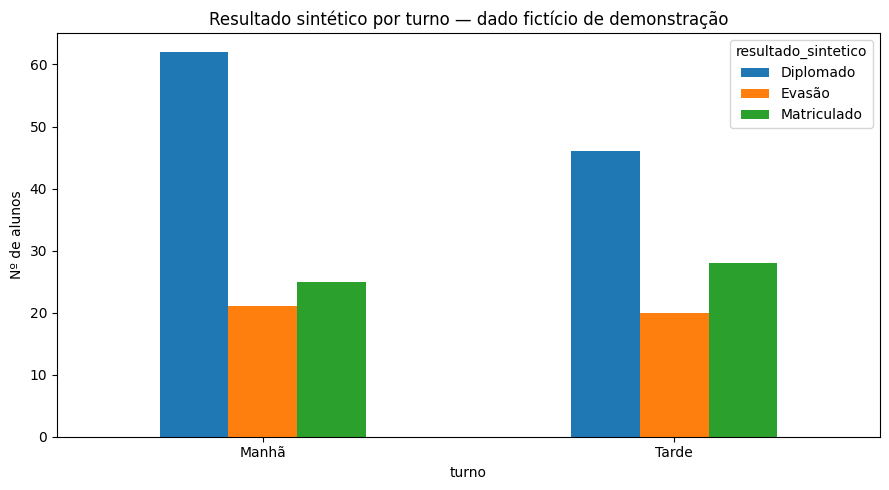

In [13]:
# 7.3 Gráfico: distribuição do rótulo sintético por turno
fig, ax = plt.subplots()
tabela_cubatao.groupby(['turno', 'resultado_sintetico']).size().unstack().plot(kind='bar', ax=ax)
ax.set_ylabel('Nº de alunos')
ax.set_title('Resultado sintético por turno — dado fictício de demonstração')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 7.4 Treinar um modelo na estrutura de Cubatão

In [14]:
# 7.4.1 Preparar X e y
features_cubatao = ['aulas_previstas', 'presencas', 'faltas', 'freq_maio', 'freq_junho',
                     'freq_julho', 'freq_agosto', 'frequencia_media', 'tendencia_pp', 'faltas_consecutivas_max']

X_cub = tabela_cubatao[features_cubatao]
y_cub = tabela_cubatao['resultado_sintetico']

X_cub_train, X_cub_test, y_cub_train, y_cub_test = train_test_split(
    X_cub, y_cub, test_size=0.25, random_state=42, stratify=y_cub
)
print(f"Treino: {len(X_cub_train)} | Teste: {len(X_cub_test)}")


Treino: 151 | Teste: 51


In [15]:
# 7.4.2 Treinar Random Forest na estrutura de Cubatão
modelo_rf_cub = RandomForestClassifier(n_estimators=300, random_state=42, max_depth=8)
modelo_rf_cub.fit(X_cub_train, y_cub_train)
pred_cub = modelo_rf_cub.predict(X_cub_test)

print("=== Random Forest — estrutura de Cubatão (rótulo sintético) ===")
print(classification_report(y_cub_test, pred_cub))


=== Random Forest — estrutura de Cubatão (rótulo sintético) ===
              precision    recall  f1-score   support

   Diplomado       0.71      0.74      0.73        27
      Evasão       0.33      0.40      0.36        10
 Matriculado       0.27      0.21      0.24        14

    accuracy                           0.53        51
   macro avg       0.44      0.45      0.44        51
weighted avg       0.52      0.53      0.52        51



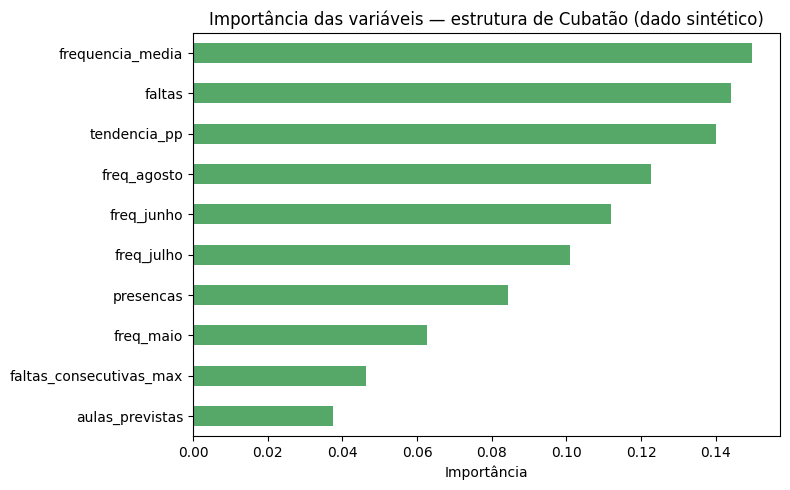

In [16]:
# 7.4.3 Importância das variáveis nesta versão
importancias_cub = pd.Series(modelo_rf_cub.feature_importances_, index=features_cubatao).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importancias_cub.plot(kind='barh', ax=ax, color='#55A868')
ax.set_xlabel('Importância')
ax.set_title('Importância das variáveis — estrutura de Cubatão (dado sintético)')
plt.tight_layout()
plt.show()


### O que este exercício mostra (e o que não mostra)

Com esta base pequena (202 alunos) e o rótulo sorteado de forma probabilística (não determinística), o modelo acertou cerca de **51%** dos casos — bem acima do acaso para 3 classes (~33%), mas longe de ser um resultado forte. Isso não é uma falha do código: é o esperado quando (a) a base é pequena e (b) o próprio rótulo tem ruído embutido no sorteio.

**Mostra:** o pipeline inteiro funciona na estrutura de dados real de Cubatão (as mesmas colunas que o registro de frequência do PI já produz) — sem precisar de nenhuma variável socioeconômica ou demográfica, só frequência e suas derivadas. O código roda de ponta a ponta e capta algum sinal real (melhor que o acaso), mesmo em uma base pequena e com rótulo ruidoso.

**Não mostra:** se este modelo funcionaria com dados reais de evasão em Cubatão. Como o rótulo é sintético (sorteado por nós, não observado na realidade) e a base é pequena, o desempenho aqui **não tem valor preditivo real** — serve só como prova de que o formato dos dados e o pipeline de treino/avaliação funcionam. Trocar o rótulo sintético por um rótulo real, e aumentar a quantidade de alunos/anos, são os dois passos que faltam para este mesmo código virar um modelo válido.


## 8. Próximos passos (atualizado)

- [ ] Citar a Seção 7 no PI como **exercício de validação técnica do pipeline**, nunca como resultado preditivo real
- [ ] Se o registro digital de frequência (protótipo HTML) for adotado de fato pela escola, substituir o rótulo sintético desta seção pelo resultado real assim que ele existir
- [ ] Manter a Seção 3 (base UCI) como a evidência de ML citável academicamente — é a única com rótulo real
- [ ] Registrar a fonte da base pública corretamente nas referências: Realinho et al. (2021), DOI 10.24432/C5MC89


## 9. Conclusão

Este notebook teve um objetivo específico: verificar se a técnica de Machine Learning supervisionado tem alguma serventia real para o problema de evasão escolar do PI, e mapear o que falta para aplicá-la de fato em Cubatão. As duas etapas, juntas, respondem a essa pergunta de forma honesta:

1. **A técnica funciona e é relevante.** Na base pública do UCI, com rótulo real, os modelos treinados (Regressão Logística e Random Forest) alcançaram entre 76% e 77% de acerto — desempenho consistente com a literatura sobre essa base. Mais importante do que o número: as variáveis que mais pesaram na previsão foram justamente as acadêmicas (unidades aprovadas, notas por período), não as socioeconômicas ou demográficas. Isso confirma, com evidência de um modelo real, que a estratégia adotada no PI — priorizar frequência e aprovação em vez de tentar levantar dados socioeconômicos sensíveis dos alunos — era a escolha certa.

2. **Falta apenas uma peça para replicar isso em Cubatão: um rótulo real.** A extensão da Seção 7 mostrou que o pipeline inteiro — carregar dados, montar features, treinar, avaliar — roda sem nenhum problema sobre a mesma estrutura de colunas que o registro de frequência do PI já produz (frequência por mês, tendência, faltas consecutivas). O desempenho modesto obtido ali (51%, com rótulo sintético) não invalida essa conclusão: ele é baixo justamente *porque* o rótulo foi sorteado artificialmente, não porque o pipeline ou as variáveis estejam erradas. É o resultado esperado quando se treina um modelo sobre um alvo com ruído embutido — e serve exatamente para isolar essa limitação, sem confundi-la com uma falha técnica.

**Conclusão prática para o PI:** o caminho para ter um modelo de Machine Learning realmente aplicável à rede municipal de Cubatão não depende de mais técnica nem de mais variáveis — depende de tempo e continuidade no registro de frequência (o protótipo entregue no PI já é esse primeiro passo), até que exista um histórico de alunos com resultado final conhecido. Quando esse dado existir, o código deste notebook — trocando apenas o rótulo sintético da Seção 7 pelo rótulo real — já está pronto para treinar esse modelo.
